In [5]:
# =========================
# Import Libraries
# =========================

# Basic Libraries
import numpy as np
import pandas as pd

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

# Sklearn Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Metrics
from sklearn.metrics import (r2_score, mean_squared_error, mean_absolute_error)

# Linear Models
from sklearn.linear_model import (LinearRegression, Ridge, Lasso, ElasticNet)

# Tree Models
from sklearn.tree import DecisionTreeRegressor

# Ensemble Models
from sklearn.ensemble import (RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor, VotingRegressor, BaggingRegressor, StackingRegressor)

# Support Vector Machine
from sklearn.svm import SVR

# KNN
from sklearn.neighbors import KNeighborsRegressor

# Boosting Libraries
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Display Settings
pd.set_option('display.max_columns', None)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [6]:
# =========================
# Load Dataset
# =========================

df = pd.read_csv("Life_Expectancy_Data.csv")

# Display first 5 rows
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,83,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,86,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,89,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,93,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,97,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [7]:
# Display last 5 rows
df.tail()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
2933,Zimbabwe,2004,Developing,44.3,723.0,27,4.36,0.0,68.0,31,27.1,42,67.0,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2
2934,Zimbabwe,2003,Developing,44.5,715.0,26,4.06,0.0,7.0,998,26.7,41,7.0,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
2935,Zimbabwe,2002,Developing,44.8,73.0,25,4.43,0.0,73.0,304,26.3,40,73.0,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0
2936,Zimbabwe,2001,Developing,45.3,686.0,25,1.72,0.0,76.0,529,25.9,39,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8
2937,Zimbabwe,2000,Developing,46.0,665.0,24,1.68,0.0,79.0,1483,25.5,39,78.0,7.10,78.0,43.5,547.358878,12222251.0,11.0,11.2,0.434,9.8


In [8]:
# =========================
# Basic Data Understanding
# =========================

print("Shape of Dataset :", df.shape)

Shape of Dataset : (2938, 22)


In [9]:
print("Columns in Dataset :")
print(df.columns)

Columns in Dataset :
Index(['Country', 'Year', 'Status', 'Life expectancy ', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure',
       'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population',
       ' thinness  1-19 years', ' thinness 5-9 years',
       'Income composition of resources', 'Schooling'],
      dtype='str')


In [10]:
# =========================
# Clean Column Names
# =========================

df.columns = df.columns.str.strip().str.title().str.replace(" ", "_")

print(df.columns)

Index(['Country', 'Year', 'Status', 'Life_Expectancy', 'Adult_Mortality',
       'Infant_Deaths', 'Alcohol', 'Percentage_Expenditure', 'Hepatitis_B',
       'Measles', 'Bmi', 'Under-Five_Deaths', 'Polio', 'Total_Expenditure',
       'Diphtheria', 'Hiv/Aids', 'Gdp', 'Population', 'Thinness__1-19_Years',
       'Thinness_5-9_Years', 'Income_Composition_Of_Resources', 'Schooling'],
      dtype='str')


In [11]:
print("Dataset Information :")
df.info()

Dataset Information :
<class 'pandas.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   str    
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   str    
 3   Life_Expectancy                  2928 non-null   float64
 4   Adult_Mortality                  2928 non-null   float64
 5   Infant_Deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   Percentage_Expenditure           2938 non-null   float64
 8   Hepatitis_B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10  Bmi                              2904 non-null   float64
 11  Under-Five_Deaths                2938 non-null   int64  
 12  Polio    

In [12]:
pd.options.display.float_format = '{:.2f}'.format
print("Statistical Summary :")
display(df.describe(include=[int, float]))

Statistical Summary :


,Year,Life_Expectancy,Adult_Mortality,Infant_Deaths,Alcohol,Percentage_Expenditure,Hepatitis_B,Measles,Bmi,Under-Five_Deaths,Polio,Total_Expenditure,Diphtheria,Hiv/Aids,Gdp,Population,Thinness__1-19_Years,Thinness_5-9_Years,Income_Composition_Of_Resources,Schooling
count,2938.00,2928.00,2928.00,2938.00,2744.00,2938.00,2385.00,2938.00,2904.00,2938.00,2919.00,2712.00,2919.00,2938.00,2490.00,2286.00,2904.00,2904.00,2771.00,2775.00
mean,2007.52,69.22,164.80,30.30,4.60,738.25,80.94,2419.59,38.32,42.04,82.55,5.94,82.32,1.74,7483.16,12753375.12,4.84,4.87,0.63,11.99
std,4.61,9.52,124.29,117.93,4.05,1987.91,25.07,11467.27,20.04,160.45,23.43,2.50,23.72,5.08,14270.17,61012096.51,4.42,4.51,0.21,3.36
min,2000.00,36.30,1.00,0.00,0.01,0.00,1.00,0.00,1.00,0.00,3.00,0.37,2.00,0.10,1.68,34.00,0.10,0.10,0.00,0.00
25%,2004.00,63.10,74.00,0.00,0.88,4.69,77.00,0.00,19.30,0.00,78.00,4.26,78.00,0.10,463.94,195793.25,1.60,1.50,0.49,10.10
50%,2008.00,72.10,144.00,3.00,3.75,64.91,92.00,17.00,43.50,4.00,93.00,5.75,93.00,0.10,1766.95,1386542.00,3.30,3.30,0.68,12.30
75%,2012.00,75.70,228.00,22.00,7.70,441.53,97.00,360.25,56.20,28.00,97.00,7.49,97.00,0.80,5910.81,7420359.00,7.20,7.20,0.78,14.30
max,2015.00,89.00,723.00,1800.00,17.87,19479.91,99.00,212183.00,87.30,2500.00,99.00,17.60,99.00,50.60,119172.74,1293859294.00,27.70,28.60,0.95,20.70


In [13]:
display(df.describe(include=[object]))

,Country,Status
count,2938,2938
unique,193,2
top,Afghanistan,Developing
freq,16,2426


In [14]:
print("Missing Values :")
df.isnull().sum().to_frame(name="Missing_Values").sort_values(by="Missing_Values", ascending=False)

Missing Values :


,Missing_Values
Population,652
Hepatitis_B,553
Gdp,448
Total_Expenditure,226
Alcohol,194
Income_Composition_Of_Resources,167
Schooling,163
Thinness__1-19_Years,34
Thinness_5-9_Years,34
Bmi,34


In [15]:
print("Duplicate Values :",df.duplicated().sum())

Duplicate Values : 0


In [16]:
# =========================
# Remove Missing Target Values
# =========================

df = df.dropna(subset=['Life_Expectancy'])

print("Shape after removing target nulls:", df.shape)

Shape after removing target nulls: (2928, 22)


In [17]:
# =========================
# Fill Missing Values
# =========================

# Numerical Columns
num_cols = df.select_dtypes(include=np.number).columns

# Fill numerical missing values with median
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

print(df.isnull().sum())

Country                            0
Year                               0
Status                             0
Life_Expectancy                    0
Adult_Mortality                    0
Infant_Deaths                      0
Alcohol                            0
Percentage_Expenditure             0
Hepatitis_B                        0
Measles                            0
Bmi                                0
Under-Five_Deaths                  0
Polio                              0
Total_Expenditure                  0
Diphtheria                         0
Hiv/Aids                           0
Gdp                                0
Population                         0
Thinness__1-19_Years               0
Thinness_5-9_Years                 0
Income_Composition_Of_Resources    0
Schooling                          0
dtype: int64


In [18]:
# =========================
# Encode Categorical Variables
# =========================

le = LabelEncoder()

df['Country'] = le.fit_transform(df['Country'])
df['Status'] = le.fit_transform(df['Status'])

df.head()

,Country,Year,Status,Life_Expectancy,Adult_Mortality,Infant_Deaths,Alcohol,Percentage_Expenditure,Hepatitis_B,Measles,Bmi,Under-Five_Deaths,Polio,Total_Expenditure,Diphtheria,Hiv/Aids,Gdp,Population,Thinness__1-19_Years,Thinness_5-9_Years,Income_Composition_Of_Resources,Schooling
0,0,2015,1,65.00,263.00,62,0.01,71.28,65.00,1154,19.10,83,6.00,8.16,65.00,0.10,584.26,33736494.00,17.20,17.30,0.48,10.10
1,0,2014,1,59.90,271.00,64,0.01,73.52,62.00,492,18.60,86,58.00,8.18,62.00,0.10,612.70,327582.00,17.50,17.50,0.48,10.00
2,0,2013,1,59.90,268.00,66,0.01,73.22,64.00,430,18.10,89,62.00,8.13,64.00,0.10,631.74,31731688.00,17.70,17.70,0.47,9.90
3,0,2012,1,59.50,272.00,69,0.01,78.18,67.00,2787,17.60,93,67.00,8.52,67.00,0.10,669.96,3696958.00,17.90,18.00,0.46,9.80
4,0,2011,1,59.20,275.00,71,0.01,7.10,68.00,3013,17.20,97,68.00,7.87,68.00,0.10,63.54,2978599.00,18.20,18.20,0.45,9.50


# MODEL 1 — WITHOUT EDA

In [19]:
df_without_eda = df.copy()
print(df_without_eda.shape)

(2928, 22)


In [20]:
df_without_eda.head()

,Country,Year,Status,Life_Expectancy,Adult_Mortality,Infant_Deaths,Alcohol,Percentage_Expenditure,Hepatitis_B,Measles,Bmi,Under-Five_Deaths,Polio,Total_Expenditure,Diphtheria,Hiv/Aids,Gdp,Population,Thinness__1-19_Years,Thinness_5-9_Years,Income_Composition_Of_Resources,Schooling
0,0,2015,1,65.00,263.00,62,0.01,71.28,65.00,1154,19.10,83,6.00,8.16,65.00,0.10,584.26,33736494.00,17.20,17.30,0.48,10.10
1,0,2014,1,59.90,271.00,64,0.01,73.52,62.00,492,18.60,86,58.00,8.18,62.00,0.10,612.70,327582.00,17.50,17.50,0.48,10.00
2,0,2013,1,59.90,268.00,66,0.01,73.22,64.00,430,18.10,89,62.00,8.13,64.00,0.10,631.74,31731688.00,17.70,17.70,0.47,9.90
3,0,2012,1,59.50,272.00,69,0.01,78.18,67.00,2787,17.60,93,67.00,8.52,67.00,0.10,669.96,3696958.00,17.90,18.00,0.46,9.80
4,0,2011,1,59.20,275.00,71,0.01,7.10,68.00,3013,17.20,97,68.00,7.87,68.00,0.10,63.54,2978599.00,18.20,18.20,0.45,9.50


In [21]:
# =========================
# Feature and Target Split
# =========================

x = df_without_eda.drop('Life_Expectancy', axis=1)

y = df_without_eda['Life_Expectancy']

print("Shape of x :", x.shape)
print("Shape of y :", y.shape)

Shape of x : (2928, 21)
Shape of y : (2928,)


In [22]:
# =========================
# Train Test Split
# =========================

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print("x_train Shape :", x_train.shape)
print("x_test Shape :", x_test.shape)
print("y_train Shape :", y_train.shape)
print("y_test Shape :", y_test.shape)

x_train Shape : (2342, 21)
x_test Shape : (586, 21)
y_train Shape : (2342,)
y_test Shape : (586,)


In [23]:
# =========================================================
# Lists to Store Model Performance
# =========================================================

model_names = []

training_scores_r2 = []
training_scores_adj_r2 = []
training_scores_rmse = []

testing_scores_r2 = []
testing_scores_adj_r2 = []
testing_scores_rmse = []


# =========================================================
# Model Evaluation Function
# =========================================================

def evaluate_model_performance(model, x_train, y_train, x_test, y_test):

    # =====================================================
    # Train the Model
    # =====================================================
    
    model.fit(x_train, y_train)

    
    # =====================================================
    # Predictions
    # =====================================================
    
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    
    # =====================================================
    # R2 Scores
    # =====================================================
    
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    
    # =====================================================
    # Adjusted R2 Scores
    # =====================================================
    
    n_train, p = x_train.shape
    n_test = x_test.shape[0]

    train_adj_r2 = 1 - ((1 - train_r2) * (n_train - 1)) / (n_train - p - 1)

    test_adj_r2 = 1 - ((1 - test_r2) * (n_test - 1)) / (n_test - p - 1)

    
    # =====================================================
    # RMSE Scores
    # =====================================================
    
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))

    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

    
    # =====================================================
    # Store Results
    # =====================================================
    
    model_names.append(model.__class__.__name__)

    training_scores_r2.append(train_r2)
    training_scores_adj_r2.append(train_adj_r2)
    training_scores_rmse.append(train_rmse)

    testing_scores_r2.append(test_r2)
    testing_scores_adj_r2.append(test_adj_r2)
    testing_scores_rmse.append(test_rmse)

    
    # =====================================================
    # Display Results
    # =====================================================
    
    print(f"{model.__class__.__name__} Performance Metrics")
    print("=" * 60)

    print("TRAINING DATA")
    print(f"R2 Score            : {train_r2:.4f}")
    print(f"Adjusted R2 Score   : {train_adj_r2:.4f}")
    print(f"RMSE Score          : {train_rmse:.4f}")

    print("-" * 60)

    print("TESTING DATA")
    print(f"R2 Score            : {test_r2:.4f}")
    print(f"Adjusted R2 Score   : {test_adj_r2:.4f}")
    print(f"RMSE Score          : {test_rmse:.4f}")

    print("\n")

In [24]:
# =========================================================
# Base Estimators for Voting & Stacking
# =========================================================

voting_estimators = [

    ('rf', RandomForestRegressor(random_state=42)),

    ('gbr', GradientBoostingRegressor(random_state=42)),

    ('xgb', XGBRegressor(random_state=42))
]


stacking_estimators = [

    ('rf', RandomForestRegressor(random_state=42)),

    ('gbr', GradientBoostingRegressor(random_state=42)),

    ('xgb', XGBRegressor(random_state=42))
]


# =========================================================
# All Regression Models
# =========================================================

models = {

    # =====================================================
    # Linear Models
    # =====================================================

    "Linear Regression": LinearRegression(),

    "Ridge Regression": Ridge(),

    "Lasso Regression": Lasso(),

    "ElasticNet Regression": ElasticNet(),


    # =====================================================
    # Tree-Based Models
    # =====================================================

    "Decision Tree": DecisionTreeRegressor(random_state=42),

    "Random Forest": RandomForestRegressor(random_state=42),


    # =====================================================
    # Ensemble Models
    # =====================================================

    "AdaBoost": AdaBoostRegressor(random_state=42),

    "Gradient Boosting": GradientBoostingRegressor(random_state=42),

    "Bagging Regressor": BaggingRegressor(random_state=42),


    # =====================================================
    # Boosting Models
    # =====================================================

    "XGBoost": XGBRegressor(random_state=42),

    "LightGBM": LGBMRegressor(random_state=42),

    "CatBoost": CatBoostRegressor(verbose=0, random_state=42),


    # =====================================================
    # Distance-Based Models
    # =====================================================

    "KNN Regressor": KNeighborsRegressor(),

    "Support Vector Regressor": SVR(),


    # =====================================================
    # Voting Regressor
    # =====================================================

    "Voting Regressor": VotingRegressor(
        estimators=voting_estimators
    ),


    # =====================================================
    # Stacking Regressor
    # =====================================================

    "Stacking Regressor": StackingRegressor(
        estimators=stacking_estimators,
        final_estimator=LinearRegression()
    )
}

In [25]:
# =========================================================
# Train and Evaluate All Models
# =========================================================

for model_name, model in models.items():

    print(f"Running Model : {model_name}")
    print()

    evaluate_model_performance(
        model,
        x_train,
        y_train,
        x_test,
        y_test
    )

Running Model : Linear Regression

LinearRegression Performance Metrics
TRAINING DATA
R2 Score            : 0.8207
Adjusted R2 Score   : 0.8191
RMSE Score          : 4.0547
------------------------------------------------------------
TESTING DATA
R2 Score            : 0.8208
Adjusted R2 Score   : 0.8141
RMSE Score          : 3.9372


Running Model : Ridge Regression

Ridge Performance Metrics
TRAINING DATA
R2 Score            : 0.8207
Adjusted R2 Score   : 0.8191
RMSE Score          : 4.0547
------------------------------------------------------------
TESTING DATA
R2 Score            : 0.8208
Adjusted R2 Score   : 0.8141
RMSE Score          : 3.9373


Running Model : Lasso Regression

Lasso Performance Metrics
TRAINING DATA
R2 Score            : 0.8112
Adjusted R2 Score   : 0.8095
RMSE Score          : 4.1608
------------------------------------------------------------
TESTING DATA
R2 Score            : 0.8085
Adjusted R2 Score   : 0.8014
RMSE Score          : 4.0697


Running Model : 

In [26]:
# =========================================================
# Model Comparison DataFrame
# =========================================================

model_comparison_df = pd.DataFrame({

    "Model": model_names,

    "Training R2": training_scores_r2,

    "Testing R2": testing_scores_r2,

    "Training Adjusted R2": training_scores_adj_r2,

    "Testing Adjusted R2": testing_scores_adj_r2,

    "Training RMSE": training_scores_rmse,

    "Testing RMSE": testing_scores_rmse
})

# Sort by Testing R2
model_comparison_df = model_comparison_df.sort_values(by="Testing R2", ascending=False)

# Reset Index
model_comparison_df.reset_index(drop=True, inplace=True)

# Display DataFrame
model_comparison_df

,Model,Training R2,Testing R2,Training Adjusted R2,Testing Adjusted R2,Training RMSE,Testing RMSE
0,StackingRegressor,1.00,0.97,1.00,0.97,0.38,1.60
1,RandomForestRegressor,0.99,0.97,0.99,0.97,0.69,1.67
2,VotingRegressor,0.99,0.97,0.99,0.97,0.85,1.67
3,XGBRegressor,1.00,0.97,1.00,0.97,0.24,1.69
4,LGBMRegressor,0.99,0.97,0.99,0.97,0.90,1.70
5,CatBoostRegressor,0.99,0.97,0.99,0.97,0.81,1.70
6,BaggingRegressor,0.99,0.96,0.99,0.96,0.86,1.87
7,GradientBoostingRegressor,0.96,0.95,0.96,0.95,1.83,2.08
8,DecisionTreeRegressor,1.00,0.92,1.00,0.92,0.00,2.63
9,AdaBoostRegressor,0.91,0.90,0.91,0.90,2.85,2.90


# MODEL 2 — AFTER EDA

In [27]:
# =========================================================
# Create Dataset for EDA Model
# =========================================================

df_with_eda = df.copy()

print(df_with_eda.shape)

(2928, 22)


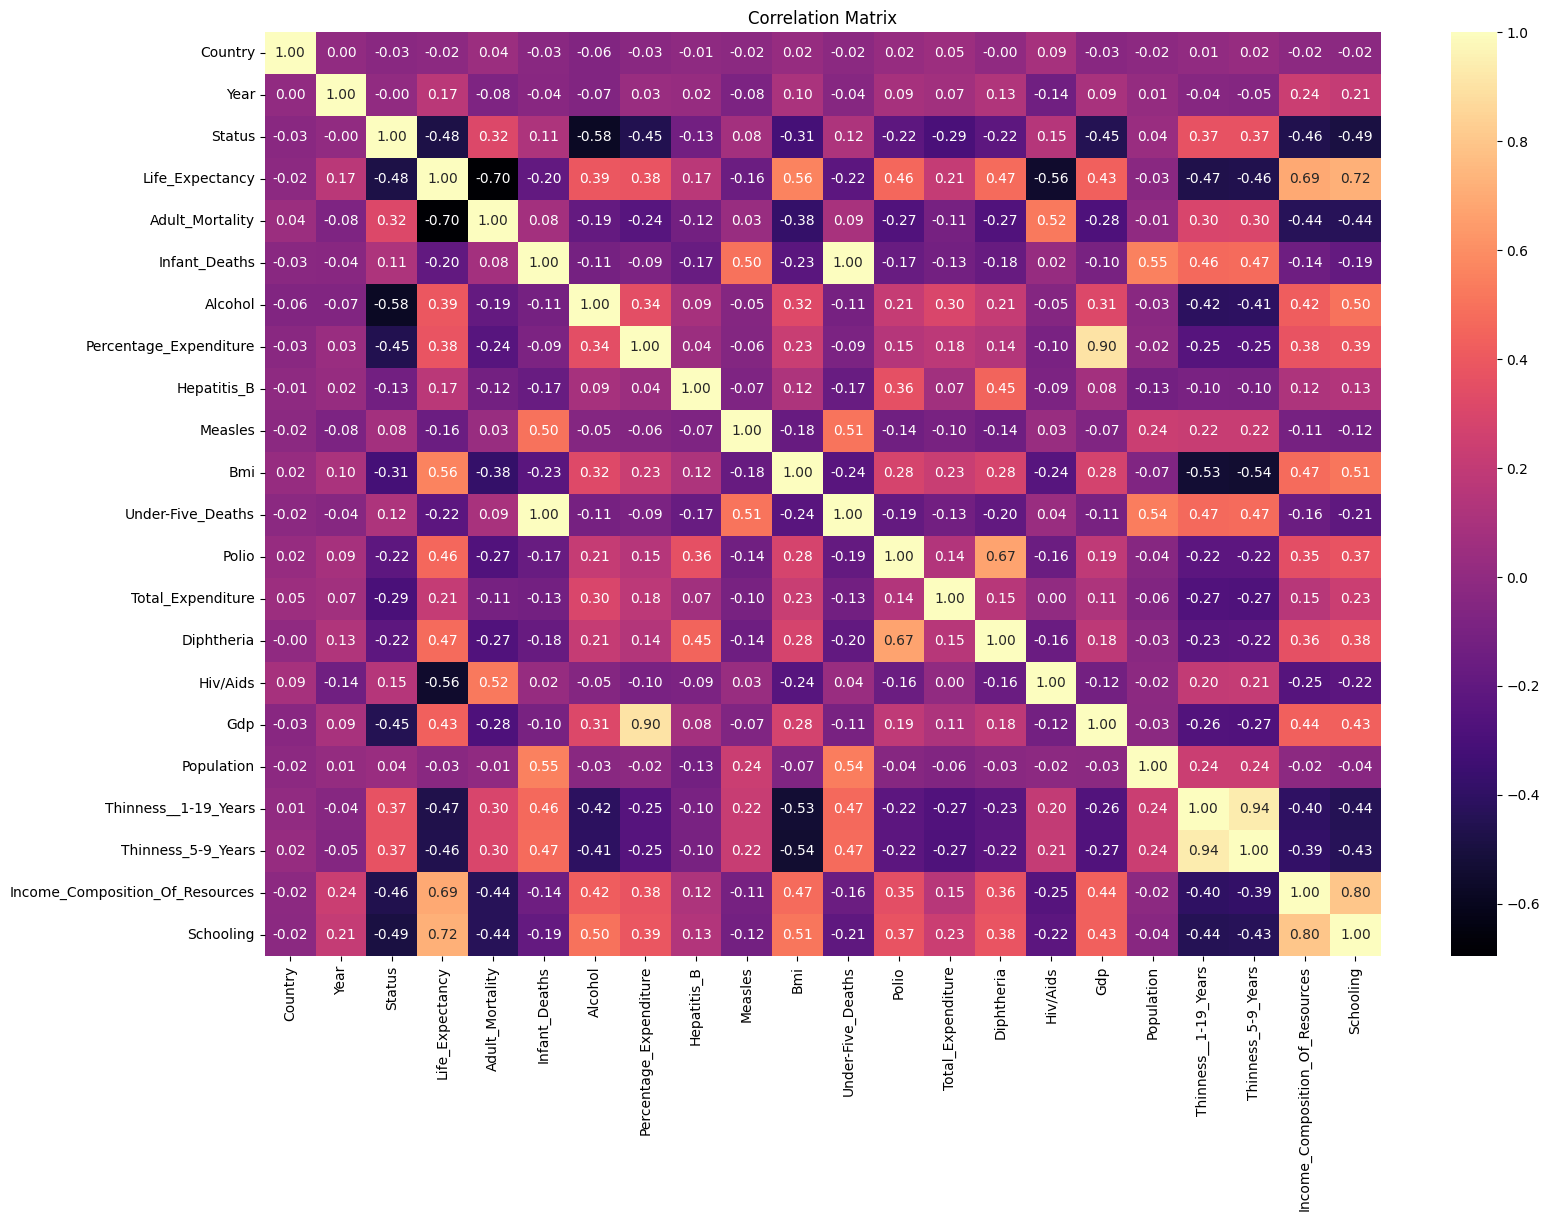

In [28]:
# =========================================================
# Correlation Matrix
# =========================================================

plt.figure(figsize=(18, 12))

sns.heatmap(df_with_eda.corr(), annot=True, cmap='magma', fmt='.2f')

plt.title("Correlation Matrix")

plt.show()

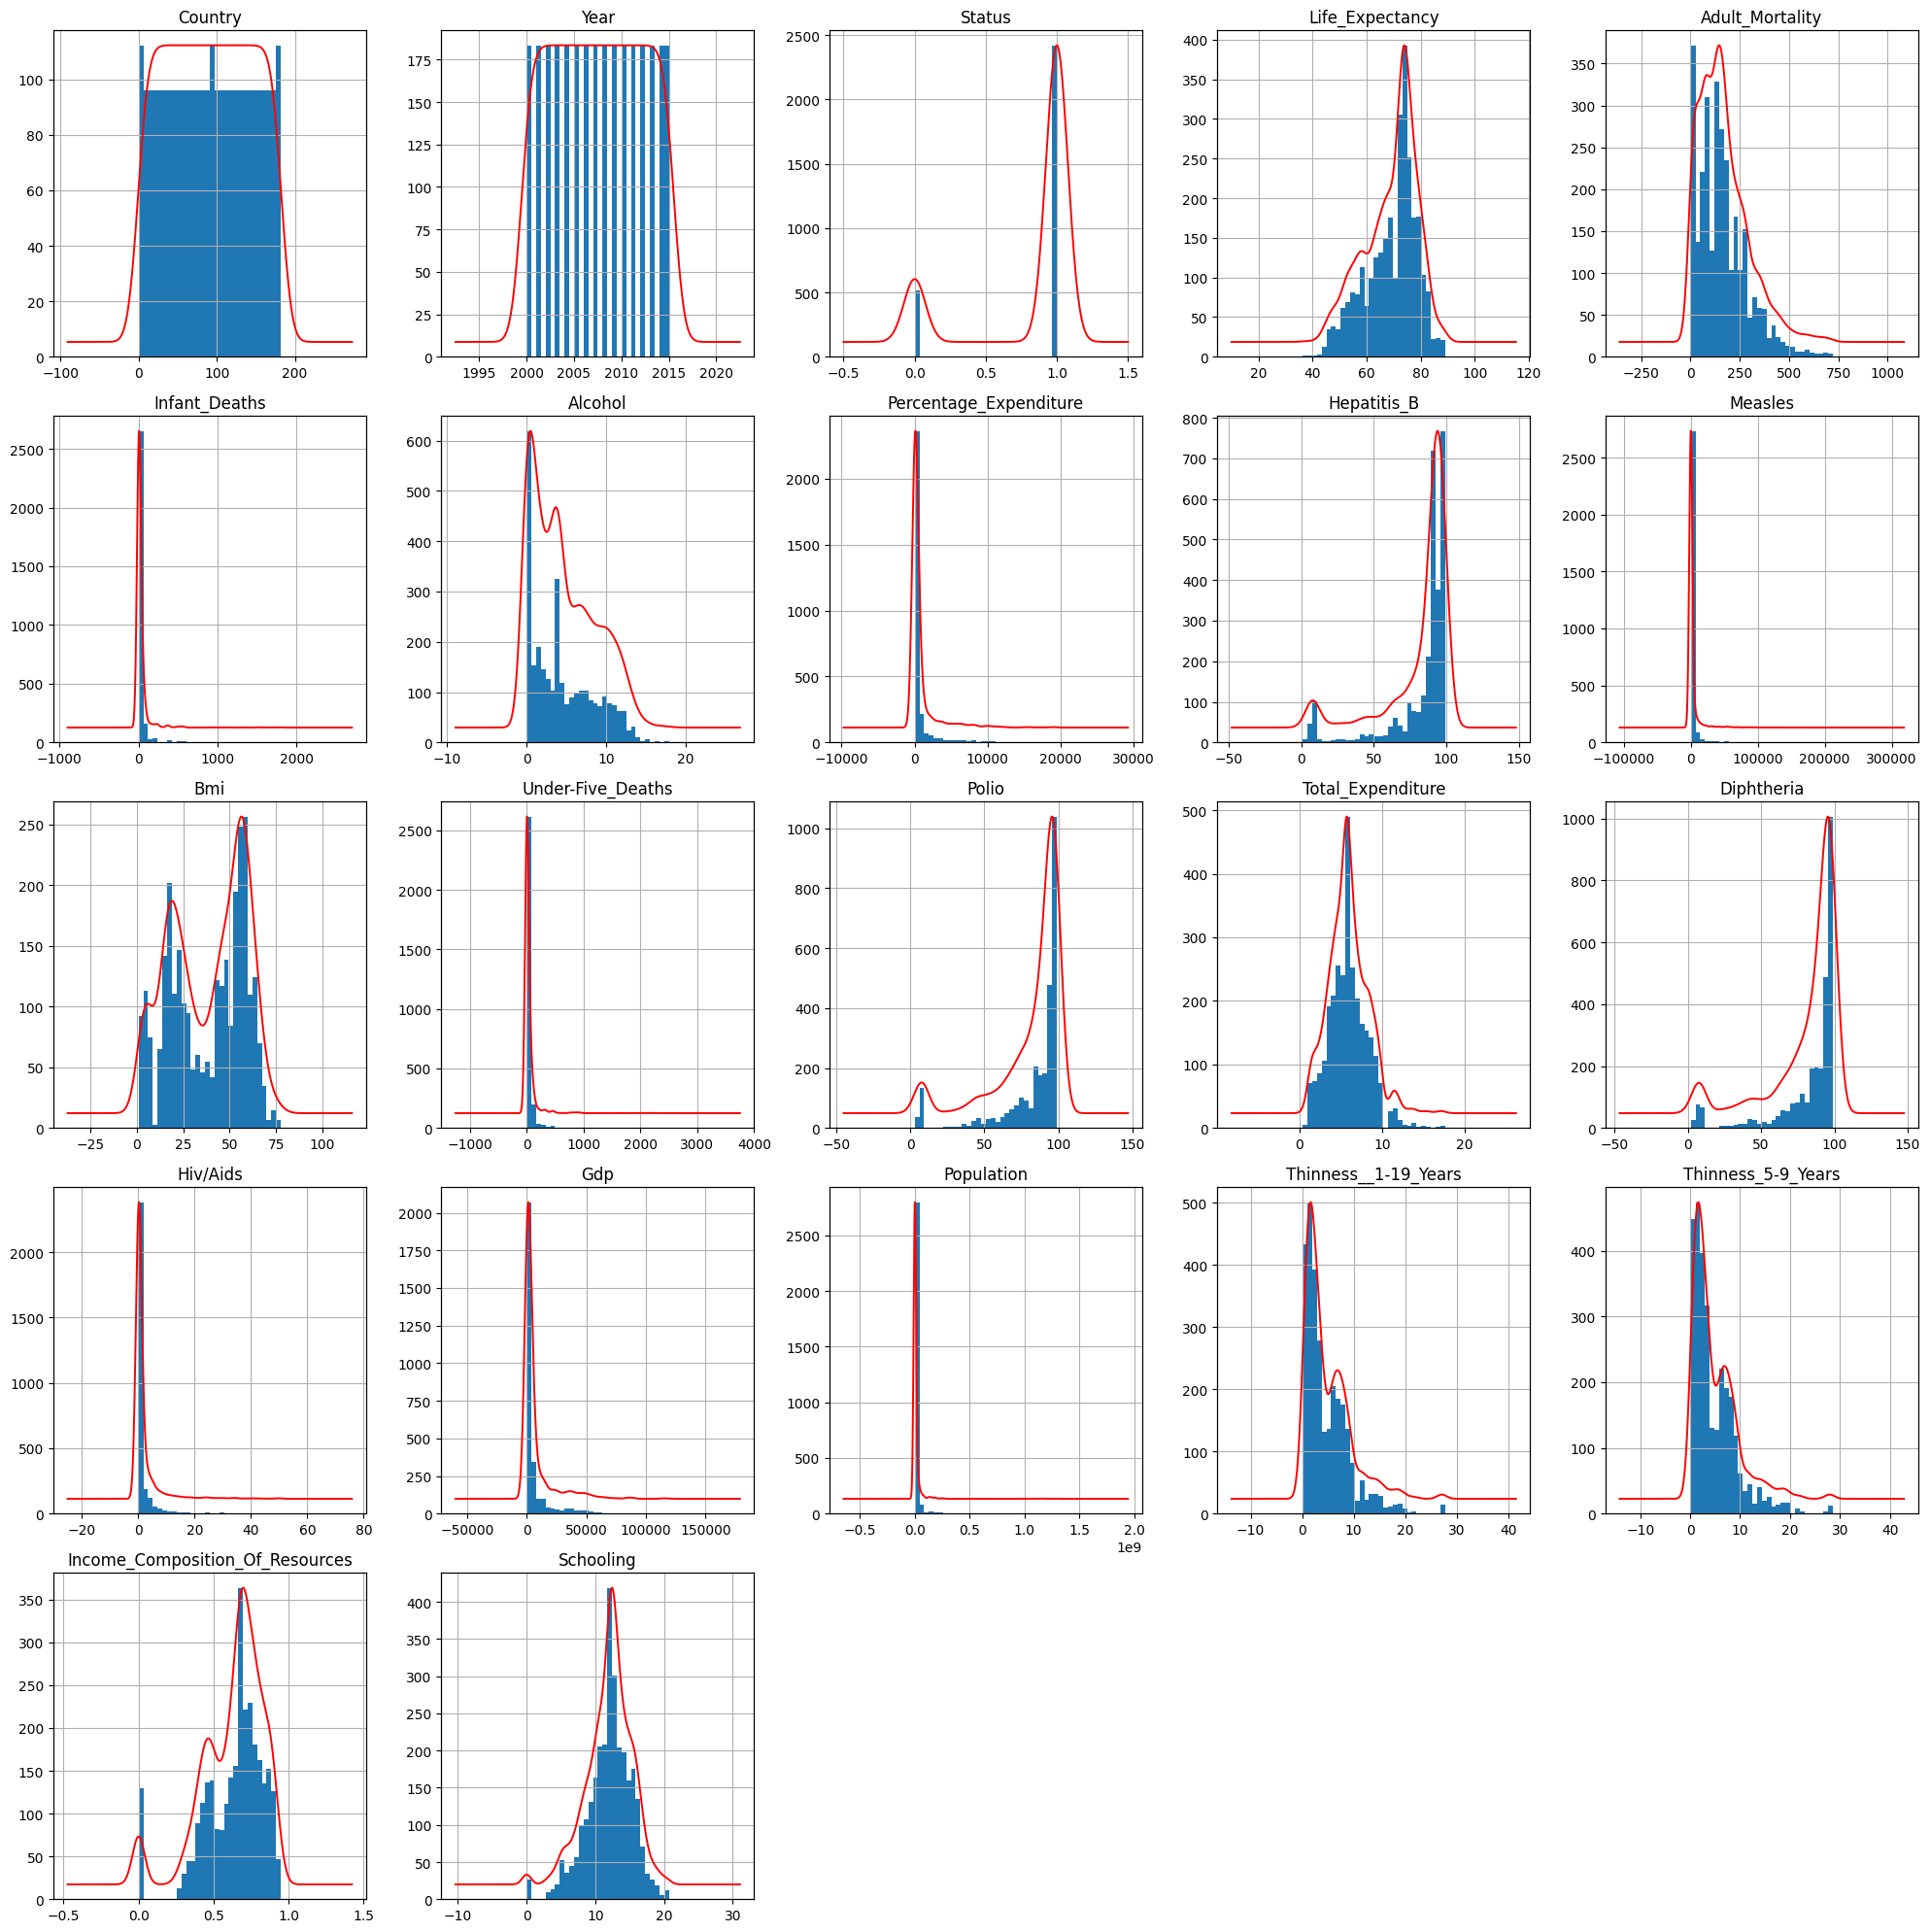

In [29]:
# =========================================================
# Histograms
# =========================================================

axes = df_with_eda.hist(
    figsize=(20, 20),
    bins=30
)

# 2. Loop through each subplot axis to add the KDE line
for ax in axes.flatten():
    # Only process subplots that actually contain data/plots
    if len(ax.get_lines()) == 0 and len(ax.patches) > 0:
        # Create a twin y-axis so the KDE density line fits perfectly
        ax_twin = ax.twinx()
        
        # Extract the column name from the title to plot its KDE
        col_name = ax.get_title()
        df_with_eda[col_name].plot(kind='kde', ax=ax_twin, color='red', linewidth=1.4)
        
        # Hide the secondary y-axis ticks to keep the look clean
        ax_twin.get_yaxis().set_visible(False)

plt.tight_layout()
plt.show()


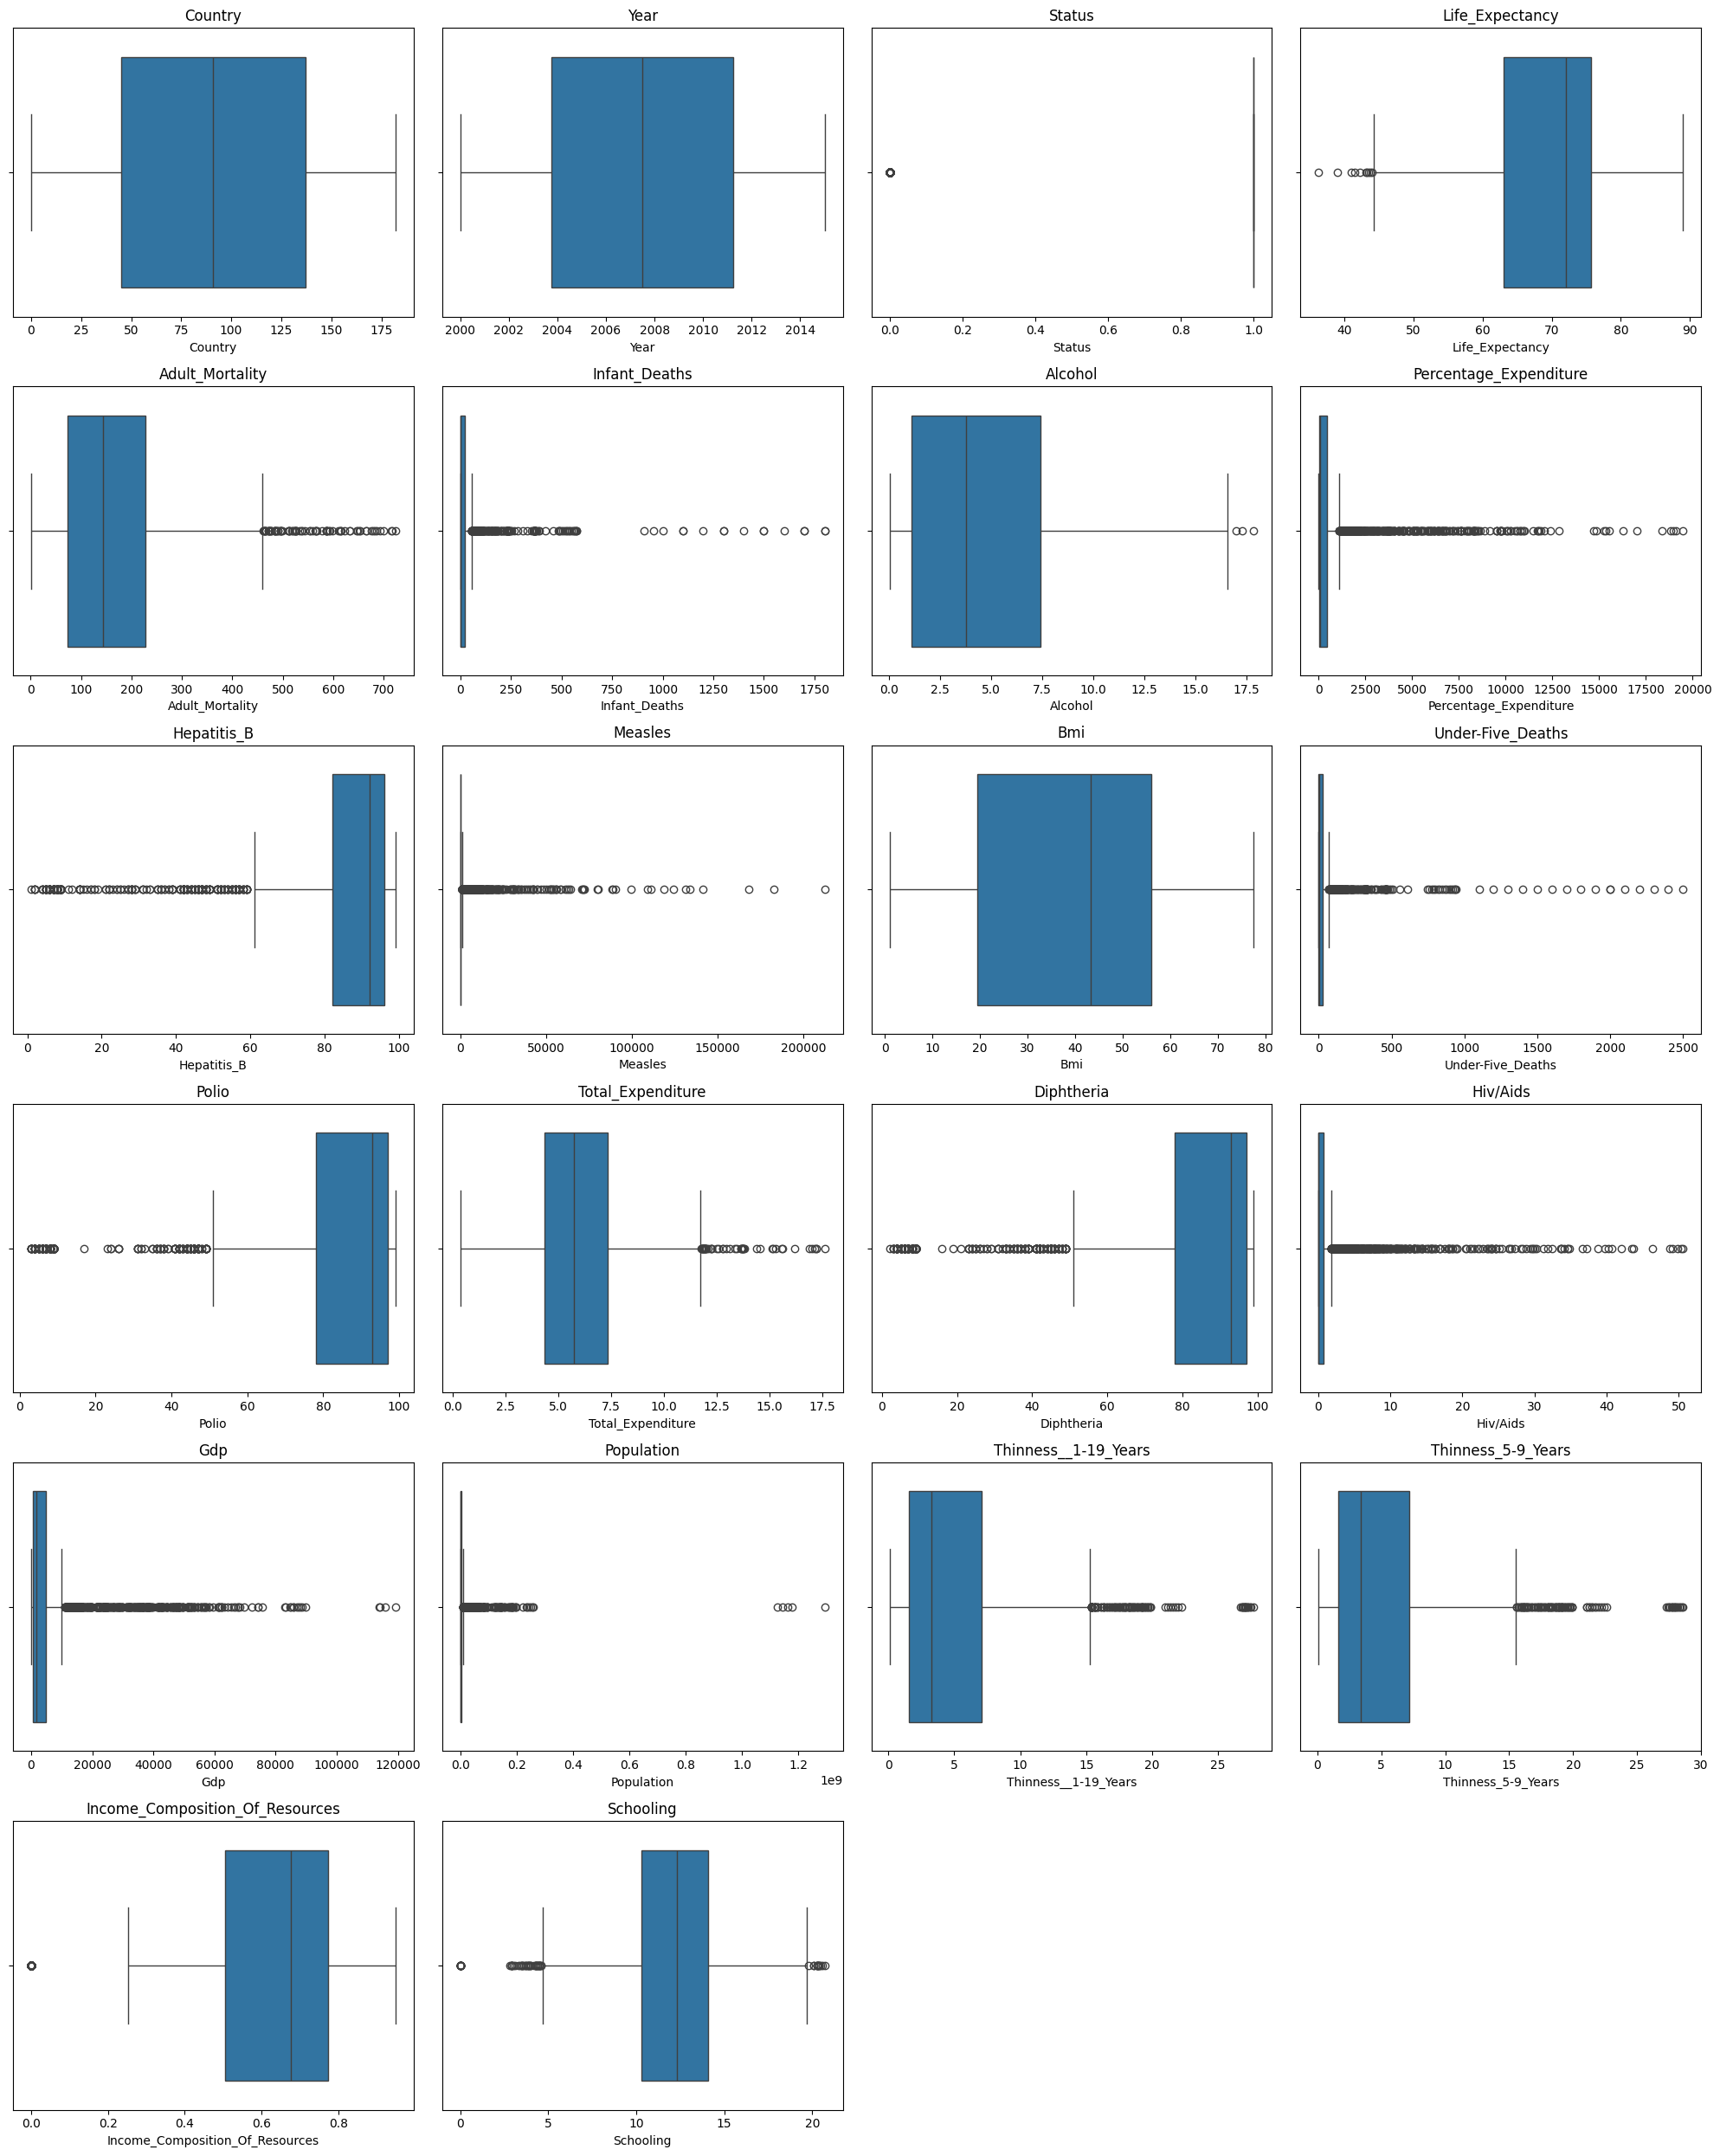

In [30]:
# =========================================================
# Boxplots for Outlier Detection
# =========================================================

plt.figure(figsize=(20, 25))

for i, col in enumerate(df_with_eda.select_dtypes(include=np.number).columns):

    plt.subplot(6, 4, i + 1)

    sns.boxplot(
        x=df_with_eda[col]
    )

    plt.title(col)

plt.tight_layout()

plt.show()

In [31]:
# =========================================================
# Features with High Skewness
# =========================================================

skewed_features = [
    'Adult_Mortality',
    'Infant_Deaths',
    'Percentage_Expenditure',
    'Measles',
    'Under-Five_Deaths',
    'Hiv/Aids',
    'Gdp',
    'Population'
]

# =========================================================
# Apply Log Transformation
# =========================================================

for feature in skewed_features:
    df_with_eda[feature] = np.log1p(df_with_eda[feature])

print("Log Transformation Applied Successfully")

Log Transformation Applied Successfully


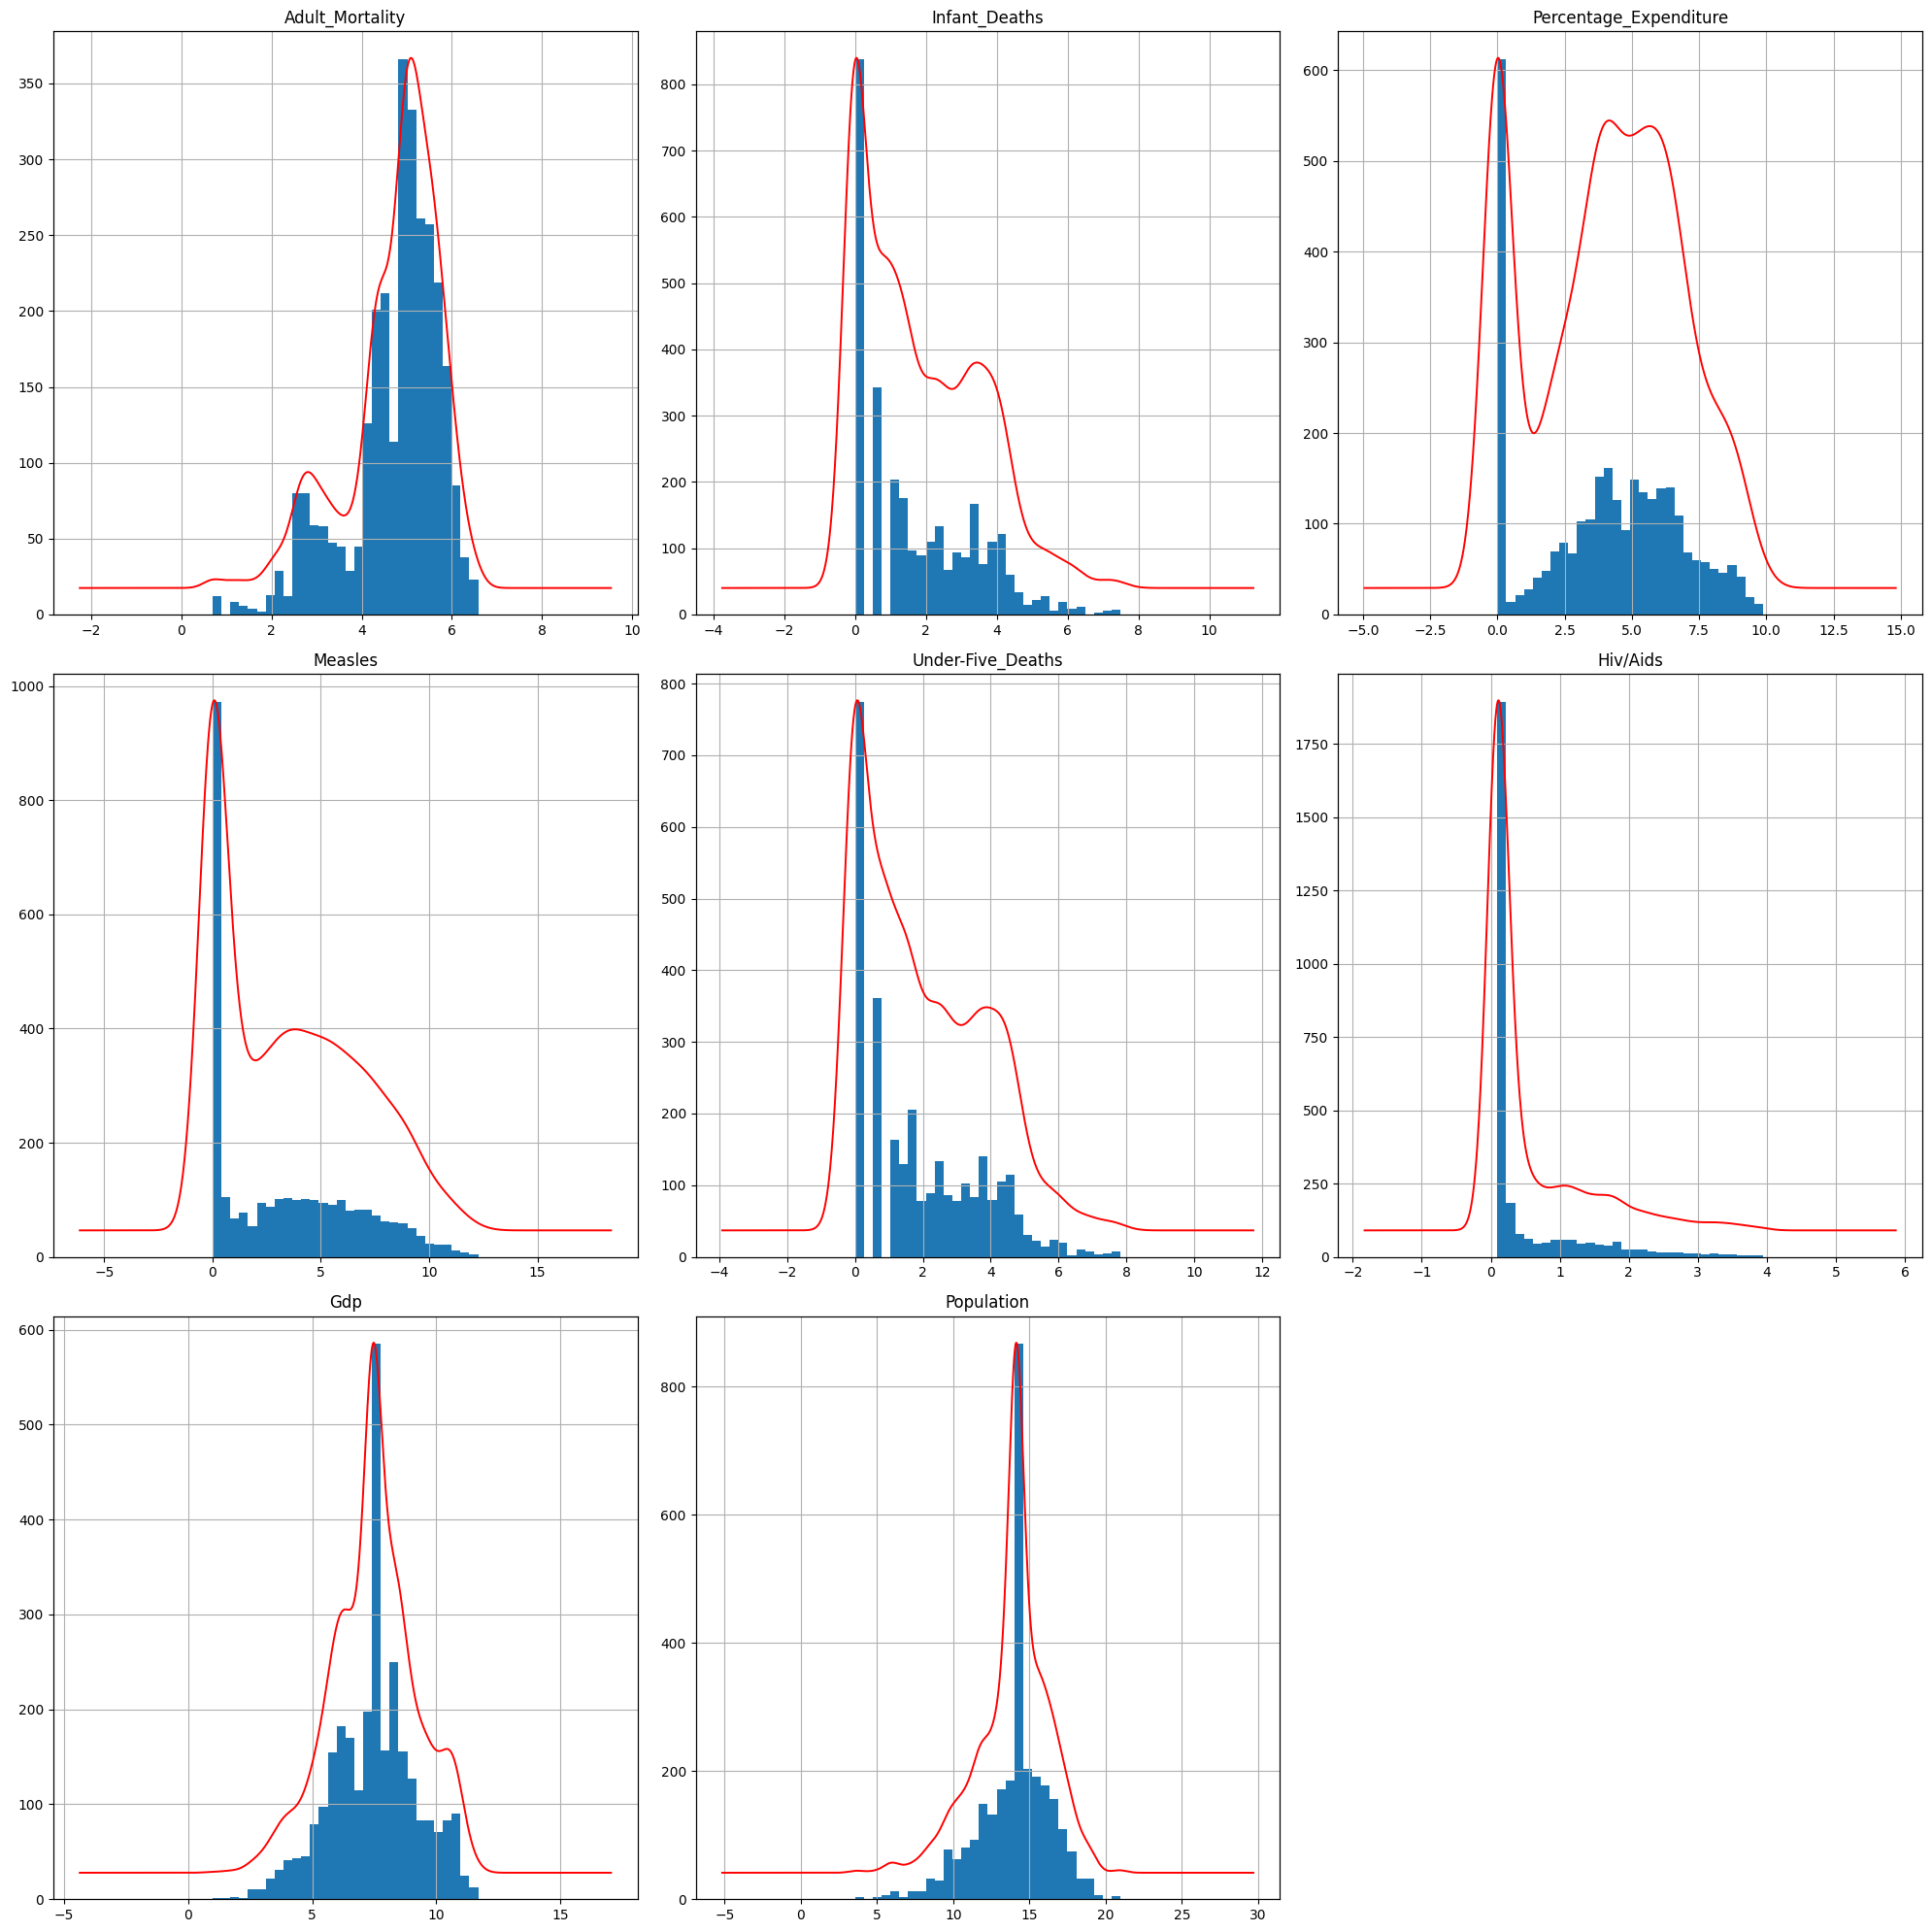

In [32]:
# =========================================================
# Histograms After Log Transformation
# =========================================================

axes = df_with_eda[skewed_features].hist(
    figsize=(20, 20),
    bins=30
)

# 2. Loop through each subplot axis to add the KDE line
for ax in axes.flatten():
    # Only process subplots that actually contain data/plots
    if len(ax.get_lines()) == 0 and len(ax.patches) > 0:
        # Create a twin y-axis so the KDE density line fits perfectly
        ax_twin = ax.twinx()
        
        # Extract the column name from the title to plot its KDE
        col_name = ax.get_title()
        df_with_eda[col_name].plot(kind='kde', ax=ax_twin, color='red', linewidth=1.4)
        
        # Hide the secondary y-axis ticks to keep the look clean
        ax_twin.get_yaxis().set_visible(False)

plt.tight_layout()
plt.show()


In [33]:
# =========================================================
# Feature and Target Split
# =========================================================

x_eda = df_with_eda.drop('Life_Expectancy', axis=1)

y_eda = df_with_eda['Life_Expectancy']

print("Shape of x_eda :", x_eda.shape)
print("Shape of y_eda :", y_eda.shape)

Shape of x_eda : (2928, 21)
Shape of y_eda : (2928,)


In [34]:
# =========================================================
# Train Test Split
# =========================================================

x_train_eda, x_test_eda, y_train_eda, y_test_eda = train_test_split(
    x_eda,
    y_eda,
    test_size=0.20,
    random_state=42
)

print("x_train_eda Shape :", x_train_eda.shape)
print("x_test_eda Shape  :", x_test_eda.shape)
print("y_train_eda Shape :", y_train_eda.shape)
print("y_test_eda Shape  :", y_test_eda.shape)

x_train_eda Shape : (2342, 21)
x_test_eda Shape  : (586, 21)
y_train_eda Shape : (2342,)
y_test_eda Shape  : (586,)


In [35]:
# =========================================================
# Feature Scaling
# =========================================================

scaler = StandardScaler()

x_train_eda_scaled = scaler.fit_transform(x_train_eda)

x_test_eda_scaled = scaler.transform(x_test_eda)

print("Feature Scaling Applied Successfully")

Feature Scaling Applied Successfully


In [36]:
# =========================================================
# Empty Lists for Model 2 Results (EDA + Scaling)
# =========================================================

model_names_eda = []

training_scores_r2_eda = []
training_scores_adj_r2_eda = []
training_scores_rmse_eda = []

testing_scores_r2_eda = []
testing_scores_adj_r2_eda = []
testing_scores_rmse_eda = []

In [37]:
# =========================================================
# Model Evaluation Function for Model 2
# =========================================================

def evaluate_model_performance_eda(model, x_train, y_train, x_test, y_test):

    # =====================================================
    # Fit Model
    # =====================================================

    model.fit(x_train, y_train)

    # =====================================================
    # Predictions
    # =====================================================

    y_train_pred = model.predict(x_train)

    y_test_pred = model.predict(x_test)

    # =====================================================
    # Training Metrics
    # =====================================================

    train_r2 = r2_score(y_train, y_train_pred)

    n_train = x_train.shape[0]

    p_train = x_train.shape[1]

    train_adj_r2 = 1 - (
        (1 - train_r2) * (n_train - 1)
        / (n_train - p_train - 1)
    )

    train_rmse = np.sqrt(
        mean_squared_error(y_train, y_train_pred)
    )

    # =====================================================
    # Testing Metrics
    # =====================================================

    test_r2 = r2_score(y_test, y_test_pred)

    n_test = x_test.shape[0]

    p_test = x_test.shape[1]

    test_adj_r2 = 1 - (
        (1 - test_r2) * (n_test - 1)
        / (n_test - p_test - 1)
    )

    test_rmse = np.sqrt(
        mean_squared_error(y_test, y_test_pred)
    )

    # =====================================================
    # Store Results
    # =====================================================

    model_names_eda.append(model.__class__.__name__)

    training_scores_r2_eda.append(round(train_r2, 4))
    training_scores_adj_r2_eda.append(round(train_adj_r2, 4))
    training_scores_rmse_eda.append(round(train_rmse, 4))

    testing_scores_r2_eda.append(round(test_r2, 4))
    testing_scores_adj_r2_eda.append(round(test_adj_r2, 4))
    testing_scores_rmse_eda.append(round(test_rmse, 4))

    # =====================================================
    # Display Results
    # =====================================================

    print(f"{model.__class__.__name__} Performance Metrics")

    print("=" * 60)

    print("TRAINING DATA")

    print(f"R2 Score            : {train_r2:.4f}")

    print(f"Adjusted R2 Score   : {train_adj_r2:.4f}")

    print(f"RMSE Score          : {train_rmse:.4f}")

    print("-" * 60)

    print("TESTING DATA")

    print(f"R2 Score            : {test_r2:.4f}")

    print(f"Adjusted R2 Score   : {test_adj_r2:.4f}")

    print(f"RMSE Score          : {test_rmse:.4f}")

    print("\n")

In [38]:
# =========================================================
# Train All Models on Scaled Data
# =========================================================

for model_name, model in models.items():

    print(f"Running Model : {model_name}")

    print()

    evaluate_model_performance_eda(
        model,
        x_train_eda_scaled,
        y_train_eda,
        x_test_eda_scaled,
        y_test_eda
    )

Running Model : Linear Regression

LinearRegression Performance Metrics
TRAINING DATA
R2 Score            : 0.8493
Adjusted R2 Score   : 0.8479
RMSE Score          : 3.7171
------------------------------------------------------------
TESTING DATA
R2 Score            : 0.8429
Adjusted R2 Score   : 0.8370
RMSE Score          : 3.6869


Running Model : Ridge Regression

Ridge Performance Metrics
TRAINING DATA
R2 Score            : 0.8492
Adjusted R2 Score   : 0.8479
RMSE Score          : 3.7179
------------------------------------------------------------
TESTING DATA
R2 Score            : 0.8428
Adjusted R2 Score   : 0.8370
RMSE Score          : 3.6871


Running Model : Lasso Regression

Lasso Performance Metrics
TRAINING DATA
R2 Score            : 0.8129
Adjusted R2 Score   : 0.8112
RMSE Score          : 4.1418
------------------------------------------------------------
TESTING DATA
R2 Score            : 0.8186
Adjusted R2 Score   : 0.8118
RMSE Score          : 3.9615


Running Model : 

In [39]:
# =========================================================
# Model 2 Results DataFrame (EDA + Scaling)
# =========================================================

model_comparison_eda_df = pd.DataFrame({

    "Model": model_names_eda,

    "Training R2": training_scores_r2_eda,

    "Testing R2": testing_scores_r2_eda,

    "Training Adjusted R2": training_scores_adj_r2_eda,

    "Testing Adjusted R2": testing_scores_adj_r2_eda,

    "Training RMSE": training_scores_rmse_eda,

    "Testing RMSE": testing_scores_rmse_eda
})

# =========================================================
# Sort by Testing R2
# =========================================================

model_comparison_eda_df = model_comparison_eda_df.sort_values(
    by="Testing R2",
    ascending=False
)

# =========================================================
# Reset Index
# =========================================================

model_comparison_eda_df.reset_index(drop=True, inplace=True)

# =========================================================
# Display Results
# =========================================================

model_comparison_eda_df

,Model,Training R2,Testing R2,Training Adjusted R2,Testing Adjusted R2,Training RMSE,Testing RMSE
0,StackingRegressor,1.00,0.97,1.00,0.97,0.38,1.60
1,RandomForestRegressor,0.99,0.97,0.99,0.97,0.69,1.67
2,VotingRegressor,0.99,0.97,0.99,0.97,0.85,1.67
3,XGBRegressor,1.00,0.97,1.00,0.97,0.24,1.69
4,LGBMRegressor,0.99,0.97,0.99,0.97,0.89,1.69
5,CatBoostRegressor,0.99,0.97,0.99,0.97,0.81,1.70
6,BaggingRegressor,0.99,0.96,0.99,0.96,0.86,1.87
7,GradientBoostingRegressor,0.96,0.95,0.96,0.95,1.83,2.09
8,DecisionTreeRegressor,1.00,0.92,1.00,0.92,0.00,2.64
9,KNeighborsRegressor,0.94,0.91,0.94,0.91,2.25,2.72


# MODEL 3 — AFTER HYPERPARAMETER TUNING

In [40]:
from sklearn.model_selection import RandomizedSearchCV

In [41]:
# =========================================================
# Random Forest Hyperparameter Grid
# =========================================================

rf_params = {

    'n_estimators': [100, 200, 300],

    'max_depth': [5, 10, 15, 20, None],

    'min_samples_split': [2, 5, 10],

    'min_samples_leaf': [1, 2, 4],

    'max_features': ['sqrt', 'log2']
}

In [42]:
# =========================================================
# Random Forest Model
# =========================================================

rf_model = RandomForestRegressor(
    random_state=42
)

In [43]:
# =========================================================
# RandomizedSearchCV for Random Forest
# =========================================================

rf_random_search = RandomizedSearchCV(

    estimator=rf_model,

    param_distributions=rf_params,

    n_iter=20,

    scoring='r2',

    cv=5,

    verbose=2,

    random_state=42,

    n_jobs=-1
)

rf_random_search.fit(
    x_train_eda_scaled,
    y_train_eda
)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [5, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... 

In [44]:
# =========================================================
# Best Parameters
# =========================================================

print("Best Parameters :")

print(rf_random_search.best_params_)

print()

print("Best Cross Validation Score :")

print(rf_random_search.best_score_)

Best Parameters :
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 15}

Best Cross Validation Score :
0.9568477833207686


In [45]:
# =========================================================
# Best Random Forest Model
# =========================================================

best_rf_model = rf_random_search.best_estimator_

best_rf_model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsampl

In [46]:
# =========================================================
# Predictions from Tuned Random Forest
# =========================================================

y_train_pred_rf = best_rf_model.predict(
    x_train_eda_scaled
)

y_test_pred_rf = best_rf_model.predict(
    x_test_eda_scaled
)

In [47]:
# =========================================================
# Training Metrics
# =========================================================

train_r2_rf = r2_score(
    y_train_eda,
    y_train_pred_rf
)

train_rmse_rf = np.sqrt(
    mean_squared_error(
        y_train_eda,
        y_train_pred_rf
    )
)

print("Training R2 Score :", round(train_r2_rf, 4))

print("Training RMSE :", round(train_rmse_rf, 4))

Training R2 Score : 0.994
Training RMSE : 0.7402


In [48]:
# =========================================================
# Testing Metrics
# =========================================================

test_r2_rf = r2_score(
    y_test_eda,
    y_test_pred_rf
)

test_rmse_rf = np.sqrt(
    mean_squared_error(
        y_test_eda,
        y_test_pred_rf
    )
)

print("Testing R2 Score :", round(test_r2_rf, 4))

print("Testing RMSE :", round(test_rmse_rf, 4))

Testing R2 Score : 0.9673
Testing RMSE : 1.6823


In [49]:
import pickle

# Save Random Forest Model from Model 1
with open('model.pkl', 'wb') as file:
    pickle.dump(models["Random Forest"], file)

print("Random Forest Model 1 Saved Successfully")

Random Forest Model 1 Saved Successfully


In [50]:
# Save Scaler
with open('scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)

print("Scaler Saved Successfully")

Scaler Saved Successfully
